# 20260907 pairwise interaction experiment — setup

Follows `../../20260721/01_setup/experiment_setup.ipynb` for the layout mechanics
(barcode grid, Echo transfer files, minibar table). What changes is **which wells
get which content**, driven by three findings from the reference-database work:

1. **The master plate cannot be assumed clean.** `merge_consensus_sequences/cross_contamination_check`
   found a few identities spreading across the collection, and wells splitting into
   more than one read cluster rose from 41% to 67% between Dec 2024 and Aug 2025.
   So *every* strain gets a monoculture well, and most get two.
2. **Pairs must be resolvable.** Only ~90% of strain pairs are >15 bp apart in 16S;
   the rest cannot be deconvolved from a mixed readout at all, so a well spent on
   them yields nothing. `separability.py` filters these out.
3. **8 strains have never yielded an ONT consensus in six attempts.** They get one
   mono and two pairs rather than a full allocation.

Plates **1-8 are self-sufficient**: sequencing only those still gives every
monoculture and the complete technical-replicate set. Plates 9+ add pair coverage
and can be read on the plate reader and frozen for later sequencing.

In [1]:
import os
import string
import itertools
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import separability as sep
import design

randseed_date = 20260907
rng = np.random.default_rng(randseed_date)

# --- capacity -------------------------------------------------------------
N_ROWS, N_COLS = 16, 24
N_PRIMARY_PLATES   = 8    # PCR'd + sequenced. Capped here because 10 was already a slog.
N_EXTENSION_PLATES = 8    # plate reader + freeze; sequence later. Can be raised toward 16.
WELLS_PER_PLATE    = (N_ROWS - 2) * (N_COLS - 2)   # 308 non-edge wells

# --- content targets ------------------------------------------------------
MONO_PER_STRAIN    = 2    # two independent monocultures -> a corroborated reference
MONO_LIMITED       = 1    # for strains that have never sequenced
N_TECHREP_PAIRS    = 50   # pairs replicated to spot-check reproducibility
TECHREP_REPLICATES = 5    # each on a different plate
MIN_SEPARATION_BP  = 15   # a pair must be at least this far apart to be worth a well
SEPARABILITY_MODE  = "conservative"   # min across all sources; see separability.py

N_PLATES = N_PRIMARY_PLATES + N_EXTENSION_PLATES
PRIMARY_CAPACITY = N_PRIMARY_PLATES * WELLS_PER_PLATE
TOTAL_CAPACITY   = N_PLATES * WELLS_PER_PLATE
print(f"{N_PLATES} plates x {WELLS_PER_PLATE} wells = {TOTAL_CAPACITY} "
      f"({PRIMARY_CAPACITY} of them sequenced)")

wells384 = np.array([r + str(c) for r in string.ascii_uppercase[:N_ROWS]
                     for c in range(1, N_COLS + 1)])
wells384_2d = wells384.reshape(N_ROWS, N_COLS)

16 plates x 308 wells = 4928 (2464 of them sequenced)


## Step 1 - strains, and what we know about each

The source plate is the 384-well master collection. Strains are split by how much
we can trust a 16S reference for them, which sets how many wells each deserves.

In [2]:
PLATE_CSV = "/home/rl/scripts/karl/merge_consensus_sequences/plate_format/Full_384_strain_collection_no_seq_info.csv"
XREF = "/home/rl/scripts/karl/merge_consensus_sequences/external_reference_crosscheck"

df_plate = pd.read_csv(PLATE_CSV)
strains = list(df_plate["Well.position"])
strain_number = dict(zip(df_plate["Well.position"], df_plate["Strain.Number"]))
print(f"{len(strains)} wells on the master plate")

status = pd.read_csv(os.path.join(XREF, "results", "well_identity_status.csv")).set_index("well")

# Which wells has ONT ever produced a consensus for (our five runs, or the
# collaborator's pool1)? Those that never have are the hard-to-lyse/sequence
# ones -- six attempts is enough evidence to stop spending wells on them.
src_of = defaultdict(set)
for line in open(os.path.join(XREF, "work", "02_ids.txt")):
    w, s, _ = line.strip().split("|")
    src_of[w].add(s)

limited = [w for w in strains if not (src_of[w] & {"ont_v3", "pool1"})]
regular = [w for w in strains if w not in limited]

df_strains = pd.DataFrame({
    "strain": strains,
    "strain_number": [strain_number[w] for w in strains],
    "n_sources": [len(src_of[w]) for w in strains],
    "sources": [";".join(sorted(src_of[w])) for w in strains],
    "identity_confirmed": [str(status.loc[w, "identity_confirmed"]) == "True"
                           if w in status.index else False for w in strains],
    "ont_sequenced_before": [w in regular for w in strains],
})
df_strains["class"] = np.where(~df_strains.ont_sequenced_before, "never_sequenced",
                       np.where(df_strains.identity_confirmed, "confirmed", "uncertain"))
print(df_strains["class"].value_counts().to_string())
print(f"\nnever sequenced despite six ONT attempts: {sorted(limited)}")
display(df_strains.head())

384 wells on the master plate
class
confirmed          307
uncertain           69
never_sequenced      8

never sequenced despite six ONT attempts: ['A4', 'A8', 'L14', 'N16', 'N2', 'N5', 'O16', 'P9']


,strain,strain_number,n_sources,sources,identity_confirmed,ont_sequenced_before,class
0,A1,1,3,ngs;pool1;sanger,False,True,uncertain
1,A2,2,4,ngs;ont_v3;pool1;sanger,True,True,confirmed
2,A3,3,4,ngs;ont_v3;pool1;sanger,True,True,confirmed
3,A4,8,1,sanger,False,False,never_sequenced
4,A5,5,3,ont_v3;pool1;sanger,True,True,confirmed


## Step 2 - which pairs are worth a well

A pair only earns a well if we expect to tell its members apart in the readout.
`separability.py` combines the four independent references conservatively: the
distance is the **minimum** over sources covering both wells, so if any source
says they are close, the pair is skipped. That direction is right because the
errors are asymmetric - an unresolvable pair yields nothing, while skipping a
resolvable one costs one of ~66,000 alternatives.

pairs >= 15 bp apart (eligible): 65991
pairs closer than that (skipped):       5774
pairs no source can compare (skipped):  1771

eligible partners per strain: median 350, min 0, strains with none: 2


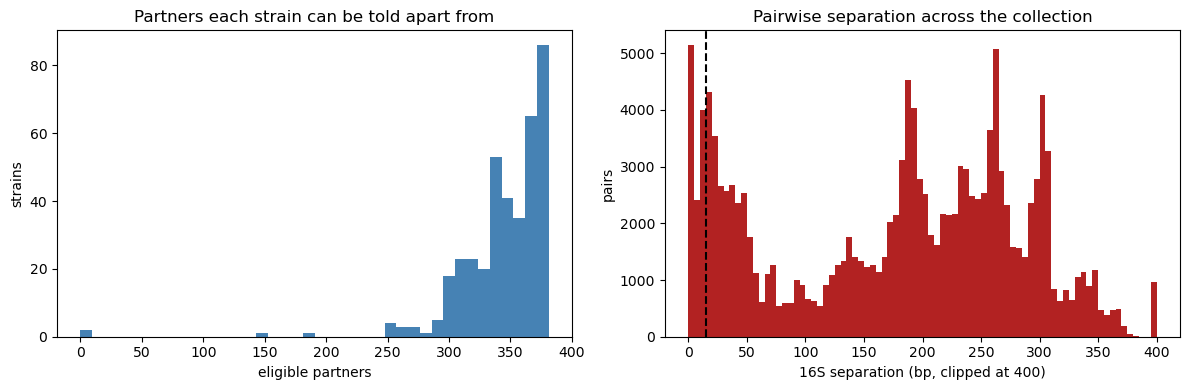

In [3]:
dist_by_source, sep_wells = sep.build(strains)
S, n_src = sep.combine(dist_by_source, sep_wells, SEPARABILITY_MODE)
idx = {w: i for i, w in enumerate(sep_wells)}
off = ~np.eye(len(strains), dtype=bool)

print(f"pairs >= {MIN_SEPARATION_BP} bp apart (eligible): {int(((S >= MIN_SEPARATION_BP) & off).sum() // 2)}")
print(f"pairs closer than that (skipped):       {int(((S >= 0) & (S < MIN_SEPARATION_BP) & off).sum() // 2)}")
print(f"pairs no source can compare (skipped):  {int(((S < 0) & off).sum() // 2)}")

def eligible(a, b):
    return S[idx[a], idx[b]] >= MIN_SEPARATION_BP

def unknown(a, b):
    """No reference can compare these two -- distinct from 'known to be close'."""
    return S[idx[a], idx[b]] < 0

partners = ((S >= MIN_SEPARATION_BP) & off).sum(axis=1)
print(f"\neligible partners per strain: median {np.median(partners):.0f}, "
      f"min {partners.min()}, strains with none: {(partners == 0).sum()}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(partners, bins=40, color="steelblue")
ax[0].set_xlabel("eligible partners"); ax[0].set_ylabel("strains")
ax[0].set_title("Partners each strain can be told apart from")
d = S[off & (S >= 0)]
ax[1].hist(np.clip(d, 0, 400), bins=80, color="firebrick")
ax[1].axvline(MIN_SEPARATION_BP, ls="--", c="k")
ax[1].set_xlabel("16S separation (bp, clipped at 400)"); ax[1].set_ylabel("pairs")
ax[1].set_title("Pairwise separation across the collection")
plt.tight_layout(); plt.show()

## Step 3 - allocate content

Budget, in priority order:

1. **Monocultures** - 2 per sequenceable strain, 1 for the never-sequenced ones.
   The two go on *different plates*, so one plate failing cannot cost both.
2. **Technical replicates** - 50 pairs at 5 copies each, every copy on a
   *different plate*. That is the only arrangement that tests plate-to-plate
   reproducibility rather than well-to-well.
3. **Distinct pairs** - successive random matchings over the strain set. One
   matching covers every strain exactly once, so *k* rounds give every strain
   exactly *k* partners with no balancing step and nobody left short.

All of 1-3 land in plates 1-8. Plates 9+ carry additional distinct pairs only.

In [4]:
n_mono = MONO_PER_STRAIN * len(regular) + MONO_LIMITED * len(limited)
n_techrep_wells = N_TECHREP_PAIRS * TECHREP_REPLICATES
n_primary_pairs = PRIMARY_CAPACITY - n_mono - n_techrep_wells
n_extension_pairs = N_EXTENSION_PLATES * WELLS_PER_PLATE

print(f"primary capacity       {PRIMARY_CAPACITY}")
print(f"  monocultures         {n_mono}   ({MONO_PER_STRAIN}x{len(regular)} + {MONO_LIMITED}x{len(limited)})")
print(f"  technical replicates {n_techrep_wells}   ({N_TECHREP_PAIRS} pairs x {TECHREP_REPLICATES})")
print(f"  distinct pairs       {n_primary_pairs}")
print(f"extension capacity     {n_extension_pairs}   (distinct pairs; plate reader + freeze)")
assert n_primary_pairs > 0, "monos + replicates already exceed the primary plates"

# N_TECHREP_PAIRS extra, because the replicated pairs are pulled out of this
# list rather than also being placed as ordinary single wells
pairs, rounds = design.build_pairs(regular, limited,
                                   n_primary_pairs + n_extension_pairs + N_TECHREP_PAIRS,
                                   eligible, rng, unknown=unknown, limited_rounds=2)
print(f"\ngenerated {len(pairs)} distinct pairs over {max(rounds) + 1} matching rounds")

appear = Counter()
for a, b in pairs:
    appear[a] += 1; appear[b] += 1
v = np.array([appear[s] for s in strains])
print(f"pair appearances per strain: min {v.min()}, median {np.median(v):.0f}, max {v.max()}")
print(f"  never_sequenced strains: {[appear[s] for s in limited]}")
bad = [(a, b) for a, b in pairs if not eligible(a, b)]
print(f"pairs used that are NOT >= {MIN_SEPARATION_BP} bp apart: {len(bad)} "
      f"(only allowed for never-sequenced strains) -> {bad[:6]}")

primary capacity       2464
  monocultures         760   (2x376 + 1x8)
  technical replicates 250   (50 pairs x 5)
  distinct pairs       1454
extension capacity     2464   (distinct pairs; plate reader + freeze)



generated 3968 distinct pairs over 22 matching rounds
pair appearances per strain: min 2, median 21, max 22
  never_sequenced strains: [2, 2, 2, 2, 2, 2, 2, 2]
pairs used that are NOT >= 15 bp apart: 4 (only allowed for never-sequenced strains) -> [('N2', 'H20'), ('N16', 'G12'), ('N16', 'D20'), ('N2', 'D2')]


## Step 4 - barcode layout

Same scheme as 20260721: 96 forward and 96 reverse barcodes in a checkerboard on
the source plate, every forward x reverse combination valid except equal indices,
giving 9120 unique combinations. Each destination well gets its own combination,
so every well is individually demultiplexable - including the extension plates,
which lets them be sequenced later without redesigning anything.

In [5]:
fprimers_full = wells384_2d[::2, ::2].flatten()     # 96 forward source wells
rprimers_full = wells384_2d[1::2, 1::2].flatten()   # 96 reverse source wells
n_fwd, n_rev = len(fprimers_full), len(rprimers_full)

combos = np.array([(i, j) for i in range(n_fwd) for j in range(n_rev) if i != j])
print(f"valid barcode combinations: {len(combos)}; wells to fill: {TOTAL_CAPACITY}")
assert len(combos) >= TOTAL_CAPACITY, "not enough unique barcode combinations"
rng.shuffle(combos)

n_cols_nonedge = N_COLS - 2
records = []
for k in range(TOTAL_CAPACITY):
    fi, rj = combos[k]
    plate  = k // WELLS_PER_PLATE + 1
    within = k %  WELLS_PER_PLATE
    dest_row = string.ascii_uppercase[(within // n_cols_nonedge) + 1]   # skip row A
    dest_col = (within % n_cols_nonedge) + 2                            # skip col 1
    records.append({"dest_plate": plate, "dest_row": dest_row, "dest_col": dest_col,
                    "dest_well": f"{dest_row}{dest_col}",
                    "fwd_idx": int(fi), "rev_idx": int(rj),
                    "fwd_source_well": fprimers_full[fi],
                    "rev_source_well": rprimers_full[rj]})
df_layout = pd.DataFrame(records)
df_layout["plate_role"] = np.where(df_layout.dest_plate <= N_PRIMARY_PLATES,
                                   "primary_sequenced", "extension_frozen")

assert (df_layout.fwd_idx == df_layout.rev_idx).sum() == 0
assert df_layout[["fwd_idx", "rev_idx"]].drop_duplicates().shape[0] == len(df_layout)
assert set(df_layout.fwd_source_well).isdisjoint(set(df_layout.rev_source_well))
print(f"layout rows: {len(df_layout)}")
display(df_layout.head())

valid barcode combinations: 9120; wells to fill: 4928


layout rows: 4928


,dest_plate,dest_row,dest_col,dest_well,fwd_idx,rev_idx,fwd_source_well,rev_source_well,plate_role
0,1,B,2,B2,40,77,G9,N12,primary_sequenced
1,1,B,3,B3,60,45,K1,H20,primary_sequenced
2,1,B,4,B4,28,71,E9,L24,primary_sequenced
3,1,B,5,B5,86,19,O5,D16,primary_sequenced
4,1,B,6,B6,45,51,G19,J8,primary_sequenced


## Step 5 - place content into wells

Monocultures and technical replicates are scattered across plates 1-8 with the
per-group spreading described above; distinct pairs fill whatever is left, the
primary plates first so that plates 1-8 stand alone.

In [6]:
primary_rows   = df_layout.index[df_layout.dest_plate <= N_PRIMARY_PLATES].to_numpy()
extension_rows = df_layout.index[df_layout.dest_plate >  N_PRIMARY_PLATES].to_numpy()
plate_of = df_layout.dest_plate.to_numpy()
content = [None] * len(df_layout)

free_by_plate = defaultdict(list)
for i in primary_rows:
    free_by_plate[plate_of[i]].append(i)
for p in free_by_plate:
    rng.shuffle(free_by_plate[p])

def take(plate):
    """Claim a free well on the given primary plate, else on the emptiest one."""
    if free_by_plate[plate]:
        return free_by_plate[plate].pop()
    alt = max(free_by_plate, key=lambda p: len(free_by_plate[p]))
    return free_by_plate[alt].pop()

primary_plates = list(range(1, N_PRIMARY_PLATES + 1))

# --- monocultures: the replicates of a strain go on different plates ---------
mono_groups = [[s] * (MONO_LIMITED if s in limited else MONO_PER_STRAIN) for s in strains]
for placed in design.spread_across_plates(mono_groups, primary_plates, rng):
    for s, p in placed:
        content[take(p)] = ("mono", s, s)

# --- technical replicates: each copy on a different plate --------------------
techrep_idx = set(rng.choice(len(pairs), size=N_TECHREP_PAIRS, replace=False).tolist())
techrep_pairs = [pairs[i] for i in sorted(techrep_idx)]
single_pairs  = [p for i, p in enumerate(pairs) if i not in techrep_idx]
placements = design.spread_across_plates(
    [[p] * TECHREP_REPLICATES for p in techrep_pairs], primary_plates, rng)
for (a, b), placed in zip(techrep_pairs, placements):
    for _, p in placed:
        content[take(p)] = ("techrep", a, b)

# --- distinct pairs: primary plates first, then the extension plates ---------
remaining = [i for p in free_by_plate for i in free_by_plate[p]]
rng.shuffle(remaining)
slots = list(remaining) + list(rng.permutation(extension_rows))
for (a, b), i in zip(single_pairs, slots):
    content[i] = ("pair", a, b)

assert all(c is not None for c in content), f"{sum(c is None for c in content)} wells unassigned"
df_layout["well_type"] = [c[0] for c in content]
df_layout["strain1"]   = [c[1] for c in content]
df_layout["strain2"]   = [c[2] for c in content]
df_layout["separation_bp"] = [int(S[idx[c[1]], idx[c[2]]]) if c[0] != "mono" else -1
                              for c in content]
print(df_layout.groupby(["plate_role", "well_type"]).size().to_string())

plate_role         well_type
extension_frozen   pair         2464
primary_sequenced  mono          760
                   pair         1454
                   techrep       250


## Step 6 - checks that the design actually delivers

These assert the promises made above rather than merely describing the output.

monocultures: every one of 384 strains present on plates 1-8
  376 strains with 2, 8 with 1
  384/384 strains have their monocultures on distinct plates
technical replicates: 50 pairs x 5, each spanning 5-5 distinct plates
pair wells below 15 bp separation: 0
pair wells of unknown separability: 4 (strains: ['D2', 'D20', 'G12', 'H20', 'N16', 'N2'])

interactions per strain on the sequenced plates: min 2, median 8, max 18
  strains below 3 interactions: 7  (expected: only the 8 never-sequenced ones)
interactions per strain across all 16 plates: min 2, median 21, max 29


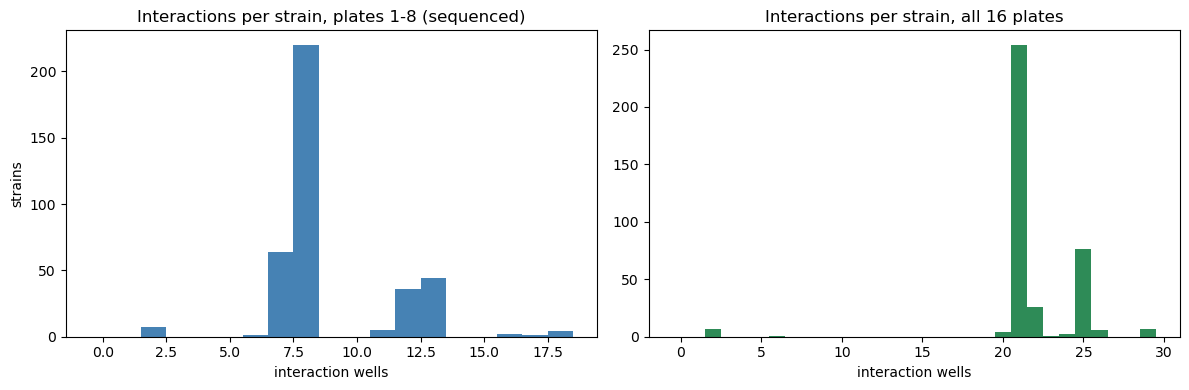

In [7]:
prim = df_layout[df_layout.dest_plate <= N_PRIMARY_PLATES]

mono_counts = Counter(prim.loc[prim.well_type == "mono", "strain1"])
assert set(mono_counts) == set(strains), "a strain has no monoculture on the primary plates"
print(f"monocultures: every one of {len(strains)} strains present on plates 1-{N_PRIMARY_PLATES}")
print(f"  {sum(1 for s in strains if mono_counts[s] == 2)} strains with 2, "
      f"{sum(1 for s in strains if mono_counts[s] == 1)} with 1")

mono_plates = defaultdict(list)
for r in prim[prim.well_type == "mono"].itertuples():
    mono_plates[r.strain1].append(r.dest_plate)
split_ok = sum(1 for s, ps in mono_plates.items() if len(ps) == len(set(ps)))
print(f"  {split_ok}/{len(mono_plates)} strains have their monocultures on distinct plates")

tr = prim[prim.well_type == "techrep"].copy()
tr["pair"] = [frozenset((a, b)) for a, b in zip(tr.strain1, tr.strain2)]
g = tr.groupby("pair").agg(n=("dest_plate", "size"), plates=("dest_plate", "nunique"))
assert (g.n == TECHREP_REPLICATES).all(), "a technical replicate set is incomplete"
print(f"technical replicates: {len(g)} pairs x {TECHREP_REPLICATES}, each spanning "
      f"{g.plates.min()}-{g.plates.max()} distinct plates")

spent = df_layout[df_layout.well_type != "mono"]
viol = spent[(spent.separation_bp >= 0) & (spent.separation_bp < MIN_SEPARATION_BP)]
unk = spent[spent.separation_bp < 0]
print(f"pair wells below {MIN_SEPARATION_BP} bp separation: {len(viol)}")
print(f"pair wells of unknown separability: {len(unk)} "
      f"(strains: {sorted(set(unk.strain1) | set(unk.strain2))})")

ap = Counter()
for r in prim[prim.well_type.isin(["pair", "techrep"])].itertuples():
    ap[r.strain1] += 1; ap[r.strain2] += 1
v = np.array([ap[s] for s in strains])
print(f"\ninteractions per strain on the sequenced plates: "
      f"min {v.min()}, median {np.median(v):.0f}, max {v.max()}")
print(f"  strains below 3 interactions: {(v < 3).sum()}  "
      f"(expected: only the {len(limited)} never-sequenced ones)")

apall = Counter()
for r in df_layout[df_layout.well_type.isin(["pair", "techrep"])].itertuples():
    apall[r.strain1] += 1; apall[r.strain2] += 1
va = np.array([apall[s] for s in strains])
print(f"interactions per strain across all {N_PLATES} plates: "
      f"min {va.min()}, median {np.median(va):.0f}, max {va.max()}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(v, bins=range(0, int(v.max()) + 2), color="steelblue", align="left")
ax[0].set_title(f"Interactions per strain, plates 1-{N_PRIMARY_PLATES} (sequenced)")
ax[0].set_xlabel("interaction wells"); ax[0].set_ylabel("strains")
ax[1].hist(va, bins=range(0, int(va.max()) + 2), color="seagreen", align="left")
ax[1].set_title(f"Interactions per strain, all {N_PLATES} plates")
ax[1].set_xlabel("interaction wells")
plt.tight_layout(); plt.show()

## Step 7 - Echo transfer files

Two 100 nL transfers per destination well. Monocultures get 100 nL of the same
strain twice, matching 20260721 so growth stays comparable with the existing data
- note this means a monoculture receives double the inoculum of either member of
a pair, which matters when comparing mono against pair yields.

In [8]:
STRAIN_VOL = 100   # nL per transfer
PRIMER_VOL = 250   # nL per primer transfer

strain_rows = []
for r in df_layout.itertuples():
    for src in (r.strain1, r.strain2):
        strain_rows.append({"Source Well": src, "Destination Plate Name": r.dest_plate,
                            "Destination Well": r.dest_well, "Transfer Volume": STRAIN_VOL})
df_strain_echo = pd.DataFrame(strain_rows)
assert len(df_strain_echo) == 2 * len(df_layout)

vol_per_source = df_strain_echo.groupby("Source Well")["Transfer Volume"].sum() / 1000
print(f"volume drawn per source well (uL): min {vol_per_source.min():.1f}, "
      f"median {vol_per_source.median():.1f}, max {vol_per_source.max():.1f}")
display(vol_per_source.sort_values(ascending=False).head())

primer_rows = []
for r in df_layout.itertuples():
    for src in (r.fwd_source_well, r.rev_source_well):
        primer_rows.append({"Source Well": src, "Destination Plate Name": r.dest_plate,
                            "Destination Well": r.dest_well, "Transfer Volume": PRIMER_VOL})
df_primer_echo = pd.DataFrame(primer_rows)
print(f"\nprimer transfers: {len(df_primer_echo)}")

volume drawn per source well (uL): min 0.4, median 2.5, max 3.3


Source Well
P19    3.3
O17    3.3
C11    3.3
A12    3.3
I3     3.3
Name: Transfer Volume, dtype: float64


primer transfers: 9856


In [9]:
df_layout.to_csv(f"strain_layout_{randseed_date}.csv", index=False)
df_strains.to_csv(f"strain_classes_{randseed_date}.csv", index=False)
df_layout.to_csv(f"primer_layout_{randseed_date}.csv", index=False)

os.makedirs("echo_strains", exist_ok=True)
os.makedirs("primer_shooting", exist_ok=True)
for p in range(1, N_PLATES + 1):
    df_strain_echo[df_strain_echo["Destination Plate Name"] == p].to_csv(
        f"echo_strains/echo_strains_{randseed_date}_plate_{p:02d}.csv", index=False)
    df_primer_echo[df_primer_echo["Destination Plate Name"] == p].to_csv(
        f"primer_shooting/echo_primers_{randseed_date}_plate_{p:02d}.csv", index=False)

df_strain_echo.to_csv(f"echo_strains_{randseed_date}.csv", index=False)
half = len(df_strain_echo) // 2
df_strain_echo.iloc[:half].to_csv(f"echo_strains_A_{randseed_date}.csv", index=False)
df_strain_echo.iloc[half:].to_csv(f"echo_strains_B_{randseed_date}.csv", index=False)
print(f"wrote per-plate Echo files for {N_PLATES} plates")

wrote per-plate Echo files for 16 plates


## Step 8 - minibar demultiplexing table

Every well across all plates gets a row, so the extension plates can be sequenced
later without regenerating anything. A primary-plates-only table is written too,
for the first sequencing run.

In [10]:
# 20260721 read this from ../../all_experiments/, which no longer exists;
# this is the same file, kept where it actually lives.
primer_specs_path = "/home/rl/scripts/karl/drug_experiments/260130_8commtest/01_pcr_setup/PrimerPlateSpecs.csv"

df_barcodes = pd.read_csv(primer_specs_path,
                          usecols=["Well Position", "Sequence Name", "Sequence"]).copy()
df_barcodes["Sequence"] = df_barcodes["Sequence"].str.replace(" ", "", regex=False)
df_barcodes["Storage"] = np.concatenate((rprimers_full, fprimers_full))[:len(df_barcodes)]

def lookup(col, name):
    return (df_layout[["dest_plate", "dest_well", col]]
            .merge(df_barcodes[["Storage", "Sequence"]], left_on=col,
                   right_on="Storage", how="left", validate="m:1")
            .rename(columns={"Sequence": name}).drop(columns=["Storage", col]))

df_minibar = lookup("fwd_source_well", "FwIndex").merge(
    lookup("rev_source_well", "RvIndex"), on=["dest_plate", "dest_well"], how="inner")
df_minibar["SampleID"] = [f"Plate{int(p):02d}_{w}" for p, w in
                          zip(df_minibar.dest_plate, df_minibar.dest_well)]
df_minibar["FwPrimer"] = "AGRGTTYGATYMTGGCTCAG"
df_minibar["RwPrimer"] = "CGGYTACCTTGTTACGACTT"
df_minibar = df_minibar[["SampleID", "FwIndex", "FwPrimer", "RvIndex", "RwPrimer"]]

assert df_minibar.FwIndex.notna().all() and df_minibar.RvIndex.notna().all()
assert df_minibar.SampleID.nunique() == len(df_minibar)
df_minibar.to_csv(f"minibar_primers_{randseed_date}.tsv", sep="\t", index=False)

primary_ids = {f"Plate{int(p):02d}_{w}" for p, w in zip(prim.dest_plate, prim.dest_well)}
df_minibar[df_minibar.SampleID.isin(primary_ids)].to_csv(
    f"minibar_primers_{randseed_date}_primary_only.tsv", sep="\t", index=False)
print(f"minibar rows: {len(df_minibar)} total, "
      f"{df_minibar.SampleID.isin(primary_ids).sum()} on the sequenced plates")
display(df_minibar.head())

minibar rows: 4928 total, 2464 on the sequenced plates


,SampleID,FwIndex,FwPrimer,RvIndex,RwPrimer
0,Plate01_B2,ATCGCCTACCGTGACATGTCCCAGTTAGAGGAGGAAACAAGRGTTY...,AGRGTTYGATYMTGGCTCAG,ATCGCCTACCGTGACGTGCAACTTTCCCACAGGTAGTTCCGGYTAC...,CGGYTACCTTGTTACGACTT
1,Plate01_B3,ATCGCCTACCGTGACTTCTCGCAAAGGCAGAAAGTAGTCAGRGTTY...,AGRGTTYGATYMTGGCTCAG,ATCGCCTACCGTGACATGCTTGTTACATCAACCCTGGACCGGYTAC...,CGGYTACCTTGTTACGACTT
2,Plate01_B4,ATCGCCTACCGTGACCTACTTACGAAGCTGAGGGACTGCAGRGTTY...,AGRGTTYGATYMTGGCTCAG,ATCGCCTACCGTGACGATTGTCCTCAAACTGCCACCTACCGGYTAC...,CGGYTACCTTGTTACGACTT
3,Plate01_B5,ATCGCCTACCGTGACGCATAGTTCTGCATGATGGGTTAGAGRGTTY...,AGRGTTYGATYMTGGCTCAG,ATCGCCTACCGTGACCAGGTTACTCCTCCGTGAGTCTGACGGYTAC...,CGGYTACCTTGTTACGACTT
4,Plate01_B6,ATCGCCTACCGTGACATGCTTGTTACATCAACCCTGGACAGRGTTY...,AGRGTTYGATYMTGGCTCAG,ATCGCCTACCGTGACCTAGACACCTTGGGTTGACAGACCCGGYTAC...,CGGYTACCTTGTTACGACTT


## Step 9 - summary

In [11]:
summary = pd.DataFrame([
    {"quantity": "plates sequenced (PCR)",           "value": N_PRIMARY_PLATES},
    {"quantity": "plates plate-reader + frozen",     "value": N_EXTENSION_PLATES},
    {"quantity": "wells sequenced",                  "value": len(prim)},
    {"quantity": "wells total",                      "value": len(df_layout)},
    {"quantity": "strains",                          "value": len(strains)},
    {"quantity": "monoculture wells",                "value": int((prim.well_type == "mono").sum())},
    {"quantity": "strains with 2 monocultures",      "value": sum(1 for s in strains if mono_counts[s] == 2)},
    {"quantity": "technical replicate wells",        "value": int((prim.well_type == "techrep").sum())},
    {"quantity": "distinct interaction pairs",       "value": len(pairs)},
    {"quantity": "  of which replicated 5x",         "value": N_TECHREP_PAIRS},
    {"quantity": "median interactions/strain (seq)", "value": float(np.median(v))},
    {"quantity": "median interactions/strain (all)", "value": float(np.median(va))},
])
display(summary)
summary.to_csv(f"design_summary_{randseed_date}.csv", index=False)

,quantity,value
0,plates sequenced (PCR),8.0
1,plates plate-reader + frozen,8.0
2,wells sequenced,2464.0
3,wells total,4928.0
4,strains,384.0
5,monoculture wells,760.0
6,strains with 2 monocultures,376.0
7,technical replicate wells,250.0
8,distinct interaction pairs,3968.0
9,of which replicated 5x,50.0
